<a href="https://colab.research.google.com/github/nitijain18/deep-learning-fruit-classifier/blob/main/fruits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download ("https://www.kaggle.com/datasets/moltean/fruits")

Skipping, found downloaded files in "./fruits" (use force=True to force download)


In [ ]:
import os
print(os.listdir())

['.config', 'fruits', 'sample_data']


In [ ]:
import os

print(os.listdir("fruits"))

['fruits-360_3-body-problem', 'fruits-360_100x100', 'fruits-360_multi', 'fruits-360_meta', 'fruits-360_original-size']


In [ ]:
import os

print(os.listdir("fruits/fruits-360_100x100"))

['fruits-360']


In [ ]:
print(os.listdir("fruits/fruits-360_100x100/fruits-360"))

['Training', 'Test', 'README.md', 'LICENSE']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout
from keras.models import Sequential

In [ ]:

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "fruits/fruits-360_100x100/fruits-360/Training",
    image_size=(256, 256),
    batch_size=32
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "fruits/fruits-360_100x100/fruits-360/Test",
    image_size=(256, 256),
    batch_size=32
)

Found 137221 files belonging to 260 classes.
Found 45724 files belonging to 260 classes.


In [ ]:
print(train_dataset.class_names)

['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20', 'Apple 21', 'Apple 22', 'Apple 23', 'Apple 5', 'Apple 6', 'Apple 7', 'Apple 8', 'Apple 9', 'Apple Braeburn 1', 'Apple Crimson Snow 1', 'Apple Golden 1', 'Apple Golden 2', 'Apple Golden 3', 'Apple Granny Smith 1', 'Apple Pink Lady 1', 'Apple Red 1', 'Apple Red 2', 'Apple Red 3', 'Apple Red Delicious 1', 'Apple Red Yellow 1', 'Apple Red Yellow 2', 'Apricot 1', 'Avocado 1', 'Avocado 2', 'Avocado Black 1', 'Avocado Black 2', 'Avocado Green 1', 'Banana 1', 'Banana 3', 'Banana 4', 'Banana Lady Finger 1', 'Banana Red 1', 'Bean pod 1', 'Beetroot 1', 'BlackBerry 4', 'Blackberry 1', 'Blackberry 2', 'Blackberry 3', 'Blackberry 5', 'Blueberry 1', 'Cabbage red 1', 'Cabbage white 1', 'Cactus fruit 1', 'Cactus fruit green 1', 'Cactus fruit red 1', 'Caju seed 1', 'Cantaloupe 1', 'Cantaloupe 2', 'Cantaloupe 3', 'Carambola 1', 'Carambola 2', 'Carambola 3', 'Carrot 1', 'Cauliflower 1'

In [ ]:
#normalizing
def process(image, label):
  image = tf.cast(image/255., tf.float32)
  return image , label

  train_dataset= train_dataset.map(process)
  test_dataset= test_dataset.map(process)

In [ ]:
from keras.src.layers import GlobalAveragePooling2D
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape= (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu', input_shape= (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu', input_shape= (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation= 'relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation= 'relu'))
model.add(Dropout(0.1))
model.add(Dense(260, activation= 'softmax'))


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 260)            │        16,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,812 (530.52 KB)

 Trainable params: 135,364 (528.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(train_dataset, epochs=10, validation_data = test_dataset)

Epoch 1/10
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 385s 86ms/step - accuracy: 0.6389 - loss: 1.1994 - val_accuracy: 0.7998 - val_loss: 1.0868
Epoch 2/10
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 360s 83ms/step - accuracy: 0.8893 - loss: 0.3172 - val_accuracy: 0.8014 - val_loss: 1.1050
Epoch 3/10
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 356s 83ms/step - accuracy: 0.9359 - loss: 0.1832 - val_accuracy: 0.9340 - val_loss: 0.6349
Epoch 4/10
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 377s 82ms/step - accuracy: 0.9544 - loss: 0.1311 - val_accuracy: 0.9516 - val_loss: 0.6929
Epoch 5/10
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 382s 82ms/step - accuracy: 0.9651 - loss: 0.1019 - val_accuracy: 0.9219 - val_loss: 0.8128
Epoch 6/10
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 351s 82ms/step - accuracy: 0.9736 - loss: 0.0787 - val_accuracy: 0.8109 - val_loss: 1.5368
Epoch 7/10
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 382s 82ms/step - accuracy: 0.9764 - loss: 0.0700 - val_accuracy: 0.9638 - val_loss: 0.7564
Epoch 8/10
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 350s 82ms/step - accuracy: 

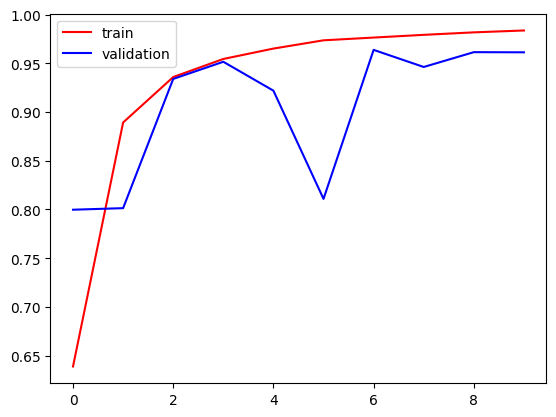

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label ='train')
plt.plot(history.history['val_accuracy'], color='blue', label ='validation')
plt.legend()
plt.show()


Saving peach.jpg to peach (2).jpg


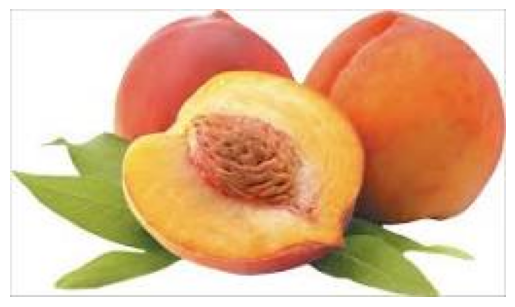

In [ ]:
from google.colab import files
uploaded = files.upload()

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("peach.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
img = cv2.resize(img, (256, 256))

In [ ]:
img = img / 255.0

In [ ]:
import numpy as np

img = np.expand_dims(img, axis=0)

In [ ]:
print(img.shape)

(1, 256, 256, 3)


In [ ]:
prediction = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
predicted_index = np.argmax(prediction)
print(predicted_index)

77


In [ ]:
print(train_dataset.class_names[predicted_index])

Cherry Wax Black 1


In [ ]:
confidence = np.max(prediction)
print(f"Predicted: {train_dataset.class_names[predicted_index]}")
print(f"Confidence: {confidence:.4f}")

Predicted: Cherry Wax Black 1
Confidence: 0.9392
